# Laboratorio 1

# Aprendizaje por Refuerzo

Francis Aguilar,
José Marchena, 22398
César López


## Task 1 (Entrega Parcial): Diseno formal del MDP

**Dominio:** una empresa de logistica urbana opera una flota de drones autonomos que recogen paquetes en puntos de origen y los entregan en direcciones dentro de una ciudad. La ciudad se abstrae como una grilla 2D de celdas (bloques urbanos x, y) que incluye edificios, zonas de vuelo restringido, estaciones de carga y puntos de entrega. Cada mision de entrega se modela como un MDP $(\mathcal{S}, \mathcal{A}, p, r, \gamma)$ para un unico dron.


## 1. Espacio de estados $\mathcal{S}$

Proponemos un estado compuesto (vector de variables discretizadas):

$$s = (x, y, \ b,\ w,\ c,)$$

| Variable | Descripcion                                                              | Justificacion de inclusion                                                                                                                                                           |
| -------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| $(x,y)$  | Posicion del dron en la grilla urbana                                    | Es la variable minima necesaria para decidir la siguiente accion de movimiento; sin ella el modelo no podria predecir a donde lleva cada accion.                                     |
| $b$      | Nivel de bateria (bins de 5%)                                            | El costo y riesgo de cada accion futura (p. ej. si conviene cargar o si un vuelo es viable) depende del presupuesto de energia restante, no de cuanta energia se gasto en el pasado. |
| $w$      | Clima/viento local (calma/moderado/fuerte) en la celda actual            | Afecta directamente la probabilidad de deriva en la transicion y el consumo de bateria del siguiente paso.                                                                           |
| $c$      | Nivel de congestion aerea en la celda/vecindad (libre/moderado/riesgoso) | Aproxima el efecto de otros drones de la flota sin modelar explicitamente sus posiciones (ver Task 2, pregunta 1).                                                                   |

**Variables que se omiten deliberadamente y su consecuencia:**

- **Destino actual** Se considera el destino actual como una constante fija del ambiente no un estado per se en la toma de decisiones. _Consecuencia:_ Esta suposicion implica que un dron tendra un solo paquete y un solo destino programado por ruta (ya sea entrega o recoger un paquete).
- **Si carga o no paquete** El modelo propuesto no da visibilidad al agente de si carga o no un paquete. Esto es similar a la restriccion anterior, pues el dron solo debera saber a donde debe ir y velar por tomar la ruta mas optima. _Consecuencia:_ se supone por tanto que un dron se comporta igual si carga un paquete o no, y que esta misma carga no tiene efecto en su movilidad, tambien supone que el destino actual es un parametro del ambiente y no un estado en la toma de decisiones. Lo que implica tambien que cada ruta o episodio es una ejecucion separada del ambiente para un mismo dron.
- **Peso y tamaño de paquete** no se consideran cuestiones como peso neto o volumen del paquete transportado, dado que se sale del scope de este laboratorio. _Consecuencia:_ esta suposicion nos lleva a que asumimos que el dron se maneobra a la misma velocidad y uso de bateria tenga o no un paquete, y si lo tiene, que el dron es capaz de recogerlo y moverlo sin problemas.
- **Tiempo de entrega**. El agente no obbserva nada sobre el tiempo, si va con atraso o si debe llegar antes de una hora. Esto se considera innecesario pues el agente deberia encontrar la ruta mas corta y segura, y aplicar alguna penalizacion por tiempo puede que solo lleve a reducir la certeza de las recompenzas. Asimismo, esto implicaria que tenemos algun conocimiento sobre la velocidad del dron o que de algun modo la podemos alterar, lo cual no es el caso.
- **Historial completo de la trayectoria pasada** (ruta seguida hasta llegar a $s$): se omite porque, si el desgaste acumulado relevante ya esta resumido en $b$ y en $\text{pkg}$, la ruta pasada no aporta informacion adicional para predecir el futuro. _Consecuencia si esto fuera falso:_ si hay desgaste mecanico dependiente de la ruta (p. ej. numero de giros bruscos) que no se refleja en los estados existentes, el modelo perderia precision y violaria Markov de forma sutil (ver Task 2).
- **Posicion exacta de los demas drones de la flota**: se omite y se reemplaza por la variable agregada $c$ (congestion). _Consecuencia:_ se pierde la capacidad de anticipar maniobras especificas de otros drones (p. ej. una colision inminente con un dron concreto); el modelo solo captura el riesgo promedio de la zona, no el riesgo instantaneo exacto.
- **Mapa meteorologico de toda la ciudad** (solo se usa la lectura local $w$): se omite por tamano de estado. _Consecuencia:_ el agente es miope ante frentes de tormenta que se aproximan pero aun no han llegado a su celda; podria entrar en una zona que se volvera peligrosa un paso despues sin haberlo anticipado.


## 2. Espacio de acciones $\mathcal{A}$

Se define un espacio de acciones **discreto**:

$$
\mathcal{A} =
    \{\text{Norte, Sur, Este, Oeste}\} \cup
    \{\text{NorEste, NorOeste, SurEste, SurOeste}\} \cup
    \{\text{Hover, Cargar}\}
$$

**Justificacion de discretizacion:** a nivel de decision logistica (a que celda moverse, cuando hover/cargar) un espacio discreto sobre una grilla de waypoints es suficiente y mucho mas tratable que control continuo de velocidades/angulos; el control de bajo nivel (estabilizacion, trayectoria fisica entre dos celdas) se delega a un controlador separado (p. ej. PID) fuera del alcance del agente de RL -- una descomposicion jerarquica habitual en robotica aerea.

**Restricciones de acciones por estado** -- se modelan mediante una funcion de acciones validas $\mathcal{A}(s) \subseteq \mathcal{A}$ (action masking):

- Movimientos diagonaes (Acciones: NorEste, NorOeste, SurEste, SurOeste) constituyen operaciones necesarias en la navegación de un dispositivo. Moverse unicamente a las celdas arriba-abajo-izquieda-derecha representan un caso irrealista e ineficiente. Estas acciones diagonales debern ser ponderadas con un factor de 1.41 o $\sqrt{2}$
- Movimientos hacia celdas de **zona de vuelo restringida** (aeropuertos, espacio aereo prohibido) quedan excluidos de $\mathcal{A}(s)$: es una restriccion fisica/legal dura, se modela por _enmascaramiento_ (la accion ni siquiera esta disponible), no por penalizacion, para garantizar que nunca se elija.
- `Hover` esta siempre disponible en $\mathcal{A}(s)$, y se mantiene como acción de seguridad si las condiciones climaticas o de congestion implican alto riesgo.
- `Cargar` solo disponible si la celda actual es una estacion de carga.


## 3. Funcion de recompensa $r(s,a,s')$

Se diseña como una combinacion ponderada de componentes que capturan los objetivos (potencialmente conflictivos) de eficiencia, bateria y seguridad, mas un costo de paso. Al no existir en el estado una variable de paquete ni un plazo $\tau$ (ver seccion 1), la recompensa ya no distingue entre "recoger" y "entregar": el unico evento relevante es llegar a la celda destino asignada por el ambiente, sea cual sea el proposito real de esa ruta. El episodio tiene exactamente dos estados terminales absorbentes: alcanzar la celda destino (exito) o agotar la bateria, $b=0$ (falla) -- no se define un estado de colision separado (ver seccion 4).

$$r(s,a,s') = r_{\text{destino}}(s,a,s') + r_{\text{bateria}}(s,a,s') + r_{\text{seguridad}}(s,a,s') + r_{\text{tiempo}}(a)$$

- $r_{\text{destino}}$: $+100$ si $s'$ corresponde a la celda destino (la posicion fija del ambiente, ver seccion 1); episodio terminal en ese caso. $0$ en cualquier otro caso -- ya no existe la nocion de "entrega tardia", pues no hay $\tau$ en el estado.
- $r_{\text{bateria}}$: $-0.1 \times \Delta b$ proporcional a la bateria consumida en el paso (si $\Delta b$ es negativo porque el dron cargo, el termino se vuelve positivo). Toda accion que mantiene al dron en el aire consume bateria -- incluido `Hover`, que si bien no desplaza al dron, si requiere energia para sostenerse -- mientras que `Cargar` la incrementa de forma segura y determinista (ver seccion 4).
- $r_{\text{seguridad}}$: $-150$ si $s'$ tiene $b'=0$ (bateria agotada) -- el unico estado terminal de falla del modelo, alcanzable tanto por agotamiento gradual de bateria como por el fallo catastrofico que la funcion de transicion asigna con mayor probabilidad bajo clima severo (ver seccion 4, Transicion 2, que se modela precisamente como una transicion directa a $b'=0$); $-20 \times \text{severidad}(w)$ si se vuela bajo condiciones climaticas severas sin llegar a $b'=0$, proporcional al riesgo real de accidente. Las estaciones de carga estan libres de este riesgo por diseño (ver seccion 4).
- $r_{\text{tiempo}}(a)$: $-1$ si $a$ es un movimiento cardinal, $-\sqrt{2}$ si es diagonal, $-1$ si $a=\text{Hover}$, y $-10$ si $a=\text{Cargar}$. El costo de `Cargar` es deliberadamente mucho mayor que el de un paso normal -- representa el costo de oportunidad de sacar al dron de servicio durante todo un ciclo de carga -- pero sigue siendo muchisimo menor que $|r_{\text{crash}}|=150$.

**Ponderacion:** se elige deliberadamente la jerarquia de magnitudes

$$|r_{\text{crash}}| > 20\times\text{severidad}(w) > r_{\text{destino}} \gg \text{costo de } \text{Cargar} > \text{costo de bateria por paso} > |r_{\text{tiempo}}|$$

de modo que **ninguna combinacion de ahorros de tiempo o bateria a lo largo de un episodio pueda compensar una unica violacion de seguridad**: la seguridad debe dominar estrictamente sobre la eficiencia y el consumo energetico. Al mismo tiempo, el costo de `Cargar` (-10) es intencionalmente mucho menor que $|r_{\text{crash}}|$ (150): un agente racional debe preferir siempre pagar el costo de una recarga antes que arriesgarse a caer por bateria agotada.

**Consecuencias de una ponderacion incorrecta:**

- Si el costo de bateria ($-0.1\Delta b$) es demasiado alto en relacion a $r_{\text{destino}}$, el agente puede aprender una politica degenerada que evita moverse para minimizar consumo, sacrificando el progreso hacia el destino -- un caso de _reward hacking_ hacia el objetivo equivocado.
- Si el costo de `Cargar` (-10) es demasiado bajo respecto a $r_{\text{destino}}$, el agente puede aprender a recargar compulsivamente en cada estacion que encuentre a su paso aunque su bateria este casi llena, usando la ausencia de riesgo de `Cargar` para evitar el riesgo de la ruta en vez de solo mitigarlo cuando sea necesario. Si, por el contrario, el costo de `Cargar` se acerca demasiado a $|r_{\text{crash}}|$, el agente preferiria arriesgarse a caer antes que pagar una recarga, lo cual es igual de indeseable -- de ahi que se calibre deliberadamente en un punto intermedio, notoriamente mayor al costo de un paso normal pero muy por debajo del costo de un accidente.
- Si el costo de `Hover` es demasiado bajo respecto al costo de movimiento, el agente puede aprender a "esperar" indefinidamente en vez de asumir el riesgo (real, pero pequeño en expectativa) de seguir volando, lo cual es ineficiente para el negocio aunque nunca sea inseguro.
- Si $r_{\text{tiempo}}$ (costo por paso) es demasiado negativo respecto a $r_{\text{seguridad}}$, el agente puede aprender a volar en clima severo para ahorrar pasos, priorizando velocidad sobre seguridad.
- Si toda la señal de recompensa depende solo del evento terminal ($r_{\text{destino}}$) sin costo de paso ni shaping, el aprendizaje es muy lento por _sparsity_ de recompensa, especialmente en grillas urbanas grandes.


## 4. Funcion de transicion $p(s' \mid s,a)$

Es **estocastica**. Fuentes reales de aleatoriedad en el dominio: viento que desvia al dron de la celda objetivo, fallos mecanicos/de sensores agravados por clima severo, variabilidad en el consumo de bateria, y un riesgo creciente de fallo catastrofico al operar con bateria critica. Las estaciones de carga, en cambio, se asumen como infraestructura confiable: no hay fallas de acoplamiento ni riesgo fisico alguno al cargar.

**Transicion 1 -- `Este` en clima calmo, bateria > 20%:**

$$p((x+1,y) \mid s,\text{Este}) = 0.90,\quad p((x+1,y{+}1)\mid s,\text{Este}) = 0.05,\quad p((x+1,y{-}1)\mid s,\text{Este}) = 0.05$$

_Justificacion:_ controladores de vuelo guiados por GPS logran alta precision en condiciones calmas, pero persiste un residual de ruido/viento leve que desplaza lateralmente al dron con baja probabilidad. En los tres casos $b' = b - \Delta b_{\text{movimiento}}$ segun el consumo normal de bateria por paso.

**Transicion 2 -- `Este` con $w=\text{fuerte}$:**

$$p(\text{intencionado}) = 0.55,\quad p(\text{deriva lateral } +y) = 0.20,\quad p(\text{deriva lateral } -y) = 0.20,\quad p(b'=0) = 0.05$$

_Justificacion:_ bajo viento fuerte aumenta considerablemente la probabilidad de desviacion lateral (empuje aerodinamico), y aparece una probabilidad no despreciable de fallo catastrofico por sobrecarga del sistema de estabilizacion -- modelado como una transicion directa a $b'=0$, el unico estado terminal de falla del modelo (ver seccion 3). Asi, el clima severo no introduce un tipo de falla distinto: simplemente adelanta el mismo desenlace terminal que el agotamiento gradual de bateria.

**Transicion 3 -- `Cargar` en estacion de carga:**

$$p(b' = \min(100, b+\Delta_{\text{carga}}) \mid s,\text{Cargar}) = 1.0$$

_Justificacion:_ se asume que las estaciones de carga son lugares puramente seguros y confiables -- sin fallas de acoplamiento ni probabilidad de fallo -- por lo que `Cargar` es la unica accion determinista del modelo. El desincentivo a abusar de `Cargar` no viene de riesgo alguno, sino del costo de tiempo asociado a la accion (ver $r_{\text{tiempo}}$, seccion 3).

**Transicion 4 -- cualquier movimiento con bateria critica ($b < 10\%$):**

$$p(\text{intencionado}) = 0.70,\quad p(\text{deriva lateral}) = 0.20 \text{ (total)},\quad p(b'=0) = 0.10$$

_Justificacion:_ agotar la bateria es un proceso fisico gradual y estocastico, no un limite abrupto: en vez de prohibir el vuelo por completo bajo bateria critica, el riesgo se expresa de forma blanda a traves de $p(s'\mid s,a)$, incrementando notablemente la probabilidad de llegar al estado terminal $b'=0$ respecto al vuelo con bateria normal (comparese con el 0% de probabilidad de $b'=0$ en la Transicion 1).

**Nota sobre estados terminales:** el MDP tiene exactamente dos estados terminales absorbentes. El primero es alcanzar la celda destino (fija, ver seccion 1), que no requiere una accion especial -- es simplemente uno de los posibles resultados estocasticos de un movimiento (Transiciones 1, 2 o 4, segun clima y bateria) -- y otorga $r_{\text{destino}}$ (ver seccion 3). El segundo es agotar la bateria, $b=0$, alcanzable tanto gradualmente (Transicion 4) como de golpe por un fallo catastrofico bajo clima severo (Transicion 2), y que otorga $r_{\text{seguridad}}=-150$. No se modela un tercer estado de colision o falla independiente: las zonas de vuelo restringido ya quedan excluidas por enmascaramiento (seccion 2), por lo que $b=0$ es la unica forma de terminar el episodio sin exito.


## 5. Factor de descuento $\gamma$

Se propone $\gamma = 0.98$.

**Justificacion en terminos del problema (no solo matematicos):**

- La tarea es episodica (ver Task 2, pregunta 3) con episodios de longitud moderada-larga (decenas o cientos de pasos al navegar una grilla urbana). Un $\gamma$ demasiado bajo descontaria casi a cero la recompensa terminal de destino ($r_{\text{destino}}$), haciendo que el agente se vuelva miope y priorice ahorros inmediatos de bateria sobre completar la ruta -- justo el comportamiento que se busca evitar.
- $\gamma=0.98$ conserva peso significativo sobre el horizonte tipico de un episodio: $0.98^{300}\approx 0.0024$, es decir, la recompensa de destino sigue siendo relevante incluso a 300 pasos de distancia.
- No se elige $\gamma=1$ aunque el episodio este garantizado a terminar en tiempo finito (por llegar al destino o por agotamiento de bateria, $b=0$, ver seccion 4): un descuento levemente menor a 1 expresa una preferencia legitima del negocio por **llegar al destino cuanto antes** entre politicas igualmente exitosas (rutas mas cortas son preferibles), y ademas captura implicitamente que **mas tiempo en vuelo implica mas exposicion acumulada a riesgo** (clima severo, mayor consumo de bateria y por tanto mayor probabilidad de terminar en $b=0$), reforzando el objetivo de seguridad.
- Si se adoptara la variante de flota operando de forma continua (ver Task 2, pregunta 3), seria necesario $\gamma$ estrictamente menor a 1 (p. ej. 0.95) para garantizar convergencia del retorno en horizonte infinito, o migrar a una formulacion de recompensa promedio (_average reward_).


---

# Task 2 (Entrega Parcial)

Respondan las siguientes preguntas con argumentacion tecnica, en base al diseno del MDP de la Task 1.


## 1. Violaciones de la propiedad de Markov

**Situacion 1 -- Clima con memoria temporal (rachas de viento / frentes de tormenta).**
El estado solo incluye la lectura instantanea de viento en la celda actual ($w$). Si el clima real tiene autocorrelacion temporal (una racha de viento no es independiente del paso anterior, o hay un frente de tormenta acercandose de forma predecible), entonces $P(w_{t+1}\mid w_t, w_{t-1},\dots) \neq P(w_{t+1}\mid w_t)$, y el estado actual deja de ser un resumen suficiente del pasado: se viola Markov.

_Extension propuesta:_ agregar al estado una ventana de las ultimas $k$ lecturas de viento, o -- mas eficiente -- el estado interno de baja dimension de un filtro (p. ej. un filtro de Kalman o un modelo autorregresivo) que resuma tendencia/aceleracion del viento, en vez de guardar el historial crudo.

_Costo computacional:_ guardar $k$ lecturas discretizadas en $L$ niveles multiplica el espacio de estados por $L^k$ (crecimiento exponencial en $k$); usar el estado resumido de un filtro mantiene el tamano del estado practicamente constante (una o dos variables continuas adicionales), a cambio de mayor costo de computo por paso (actualizar el filtro) y de perder la interpretacion tabular directa, lo que tipicamente obliga a usar aproximacion de funcion en vez de una tabla $Q(s,a)$.

**Situacion 2 -- Congestion aerea como variable agregada de otros agentes.**
El estado resume la posicion e intenciones de los demas drones de la flota en una sola variable $c$ (nivel de congestion). La probabilidad real de colision/retraso en el siguiente paso depende de las posiciones y rutas planeadas de esos otros drones, informacion que no esta en $s$. Si la congestion evoluciona de forma predecible (patrones de hora pico) mas alla de lo que la lectura actual de $c$ captura, el estado deja de ser suficiente: se viola Markov.

_Extension propuesta:_ incluir en el estado las posiciones (o rutas planeadas) de los drones vecinos dentro de un radio $r$, o un mapa de congestion discretizado sobre la vecindad inmediata en vez de un unico escalar agregado.

_Costo computacional:_ incluir posiciones exactas de $N$ drones vecinos multiplica el espacio de estados por (numero de celdas)$^N$ -- crecimiento exponencial en $N$, impracticable para flotas grandes. La alternativa de un mapa de congestion local (vecindad de tamano fijo) crece solo linealmente en el numero de celdas vecinas consideradas, sacrificando precision (no distingue que dron especifico genera el riesgo) a cambio de escalabilidad.

**Situacion 3 (adicional) -- Desgaste acumulado real de la bateria.**
El porcentaje de bateria reportado por el sensor no siempre refleja la capacidad real restante: dos drones con el mismo $b\%$ pero distinto historial de ciclos de carga/temperatura pueden comportarse de forma distinta ante la misma accion. Si $b$ no captura ese estado fisico (_state of health_), se viola Markov.

_Extension propuesta:_ agregar una variable de salud de bateria (SoH) o numero de ciclos de carga, actualizada lentamente entre episodios. _Costo computacional:_ bajo -- una unica variable discreta adicional con pocos niveles.


## 2. Observabilidad completa en logistica urbana

Asumir observabilidad completa **no es completamente razonable**, es una simplificacion conveniente adoptada al modelar el problema como MDP en vez de POMDP.

**Variables del estado real probablemente no observables directamente por el dron:**

- Posicion y trayectoria exacta de otros drones/obstaculos moviles fuera del rango o linea de vista de los sensores (de ahi que se use la variable agregada de congestion $c$ y no posiciones exactas).
- Condiciones meteorologicas fuera de la celda actual (viento en la ruta futura todavia no medido).
- El estado interno real de la bateria (quimica, _state of health_) -- solo se observa una estimacion indirecta ($b\%$) calculada por el sistema de gestion de bateria, con error.
- Posicion exacta del propio dron: en entornos urbanos con edificios altos, el GPS sufre el efecto de _urban canyon_ (multipath, perdida de senal), por lo que $(x,y)$ observado es en realidad una estimacion ruidosa de la posicion real.
- Disponibilidad real de la estacion de carga en el instante exacto de llegada (p. ej. otro dron ocupandola) si no hay comunicacion perfecta en tiempo real.
- Fallas incipientes de hardware (degradacion de motor) no detectadas aun por los sensores.

**Efecto sobre la validez MDP vs. POMDP:**

Un MDP asume que la observacion disponible para el agente **es** el estado real y suficiente estadisticamente. Si en realidad el dron solo tiene acceso a una observacion ruidosa/parcial $o_t = g(s_t) + \epsilon$ (lo cual es el caso aqui), el problema es formalmente un **POMDP**: la decision optima deberia basarse en una distribucion de creencia (_belief state_) sobre los estados posibles dado el historial de observaciones, no en la observacion cruda de un solo instante.

Tratarlo como MDP (usar la lectura de sensores directamente como si fuera el estado) es una aproximacion razonable cuando el ruido es pequeno y las variables no observadas tienen bajo impacto en la dinamica relevante -- justificable, por ejemplo, para posicion y bateria con buena instrumentacion. Se degrada, en cambio, cuando la incertidumbre es alta (clima cambiante, comportamiento de otros agentes), caso en el que conviene mantener explicitamente un _belief state_ (POMDP) o al menos una aproximacion intermedia (_belief MDP_ con un filtro/historial corto embebido en el estado), aceptando el costo computacional adicional que eso implica.


## 3. ¿Tarea episodica o continua?

**Argumento:** este problema deberia modelarse como **episodico**, con un episodio = una ruta del dron hacia la celda destino asignada (indistintamente si el proposito real es recoger o entregar un paquete, ver Task 1 seccion 1). Existen exactamente dos estados terminales, ambos absorbentes: **exito**, al alcanzar la celda destino ($r_{\text{destino}}=+100$), y **falla**, al agotar la bateria ($b=0$, $r_{\text{seguridad}}=-150$) -- ya sea por consumo gradual o por el fallo catastrofico que el clima severo puede precipitar (Task 1, seccion 4). No se define un estado de colision independiente: las zonas de vuelo restringido ya quedan excluidas por enmascaramiento, asi que $b=0$ es la unica forma de terminar sin exito. Operacionalmente, la empresa tambien gestiona el negocio en unidades discretas de "ruta", no como un proceso ininterrumpido sin reinicio.

Una vista alternativa **continua** seria razonable solo si se modela la operacion agregada de toda la flota a lo largo del dia como un unico proceso perpetuo (el dron llega a destino, vuelve a base, recarga y encadena la siguiente ruta sin un punto de reinicio natural) -- mismo agente, sin estados absorbentes.

**Como cambia el diseno segun la decision:**

|                | Episodica (recomendado)                                                                                                                                                                                      | Continua                                                                                                                                                                                                                                                            |
| -------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Recompensa** | Puede anclarse a los dos eventos terminales claros ($r_{\text{destino}}=+100$ o $b=0$ con $r_{\text{seguridad}}=-150$ al llegar a un estado absorbente); el retorno por episodio es finito por construccion. | No hay un evento terminal unico que reiniciar; se necesita una formulacion de tasa (p. ej. recompensa promedio por unidad de tiempo, o $+R$ repetible cada vez que se alcanza un destino dentro de un flujo continuo), evitando que la suma de recompensas diverja. |
| **$\gamma$**   | Puede ser alto, incluso cercano a 1 (aqui se propuso 0.98), porque el horizonte es finito y la suma de recompensas esta garantizada acotada.                                                                 | Debe ser estrictamente menor a 1 (p. ej. 0.90-0.95) para que el retorno descontado converja en horizonte infinito, o bien sustituirse por una formulacion de _average reward_ en vez de recompensa descontada.                                                      |

**Conclusion:** se recomienda la formulacion episodica porque es mas natural para el dominio, produce objetivos de exito/fracaso claros por ruta, facilita el entrenamiento (retornos de Monte Carlo por episodio) y da metricas de negocio directamente interpretables (tasa de exito, tiempo promedio y consumo por ruta). La vista continua solo aportaria valor si el objetivo fuera optimizar el comportamiento agregado de la flota en operacion 24/7 sin puntos de reinicio identificables entre rutas.


## Task 3

Implementen en Python un evaluador iterativo de políticas para un GridWorld 5x5 que represente la ciudad de drones. Su implementación debe:

- Representar el MDP completo: estados, acciones, función de transición y función de recompensa, consistentes con el diseño de la Tarea 1. No usen librerías de RL como Gymnasium. El MDP debe estar implementado desde cero.

- Implementar la evaluación iterativa de políticas mediante aplicación repetida del operador de Bellman hasta convergencia. El criterio de convergencia debe ser configurable: el algoritmo termina cuando el cambio máximo en cualquier valor de estado entre dos iteraciones consecutivas es menor que un umbral 𝜃.

- Evaluar y comparar al menos tres políticas distintas: la política uniforme aleatoria, una política determinista fija definida por ustedes, y la política greedy derivada de los valores de la política anterior.

- Producir para cada política evaluada: una tabla de valores 𝑉𝜋(𝑠)para todos los estados, el número de iteraciones hasta convergencia, y una visualización del grid con los valores codificados en color y las acciones de la política greedy superpuestas como flechas


In [2]:
from model import (
    GridWorld,
    uniform_random_policy,
    fixed_policy,
    greedy_policy_from_V,
    evaluate_and_report,
)

env = GridWorld()

x,0,1,2,3,4
y,,,,,
4,-323.572321,-260.795241,-221.937501,-114.130206,0.000000
3,-330.679234,NaN,-200.051387,-140.006838,-119.956992
2,-299.460771,-291.397182,NaN,-219.656855,-238.228702
1,-305.726231,-316.439315,-348.668414,NaN,-325.371248
0,-350.044672,-325.769663,-365.931538,-358.889167,-330.622487


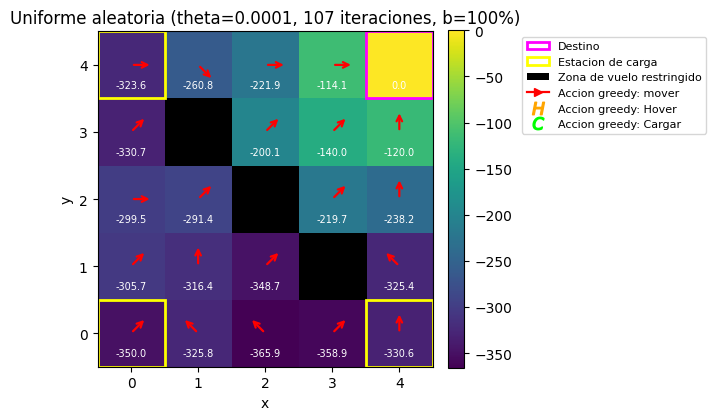

In [3]:
env = GridWorld()
V1, it1, t1, f1 = evaluate_and_report(env, uniform_random_policy, "Uniforme aleatoria")
t1

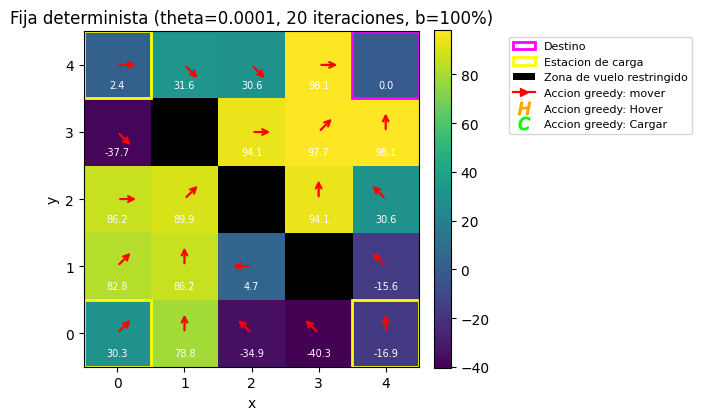

In [4]:
V2, it2, t2, f2 = evaluate_and_report(env, fixed_policy, "Fija determinista")

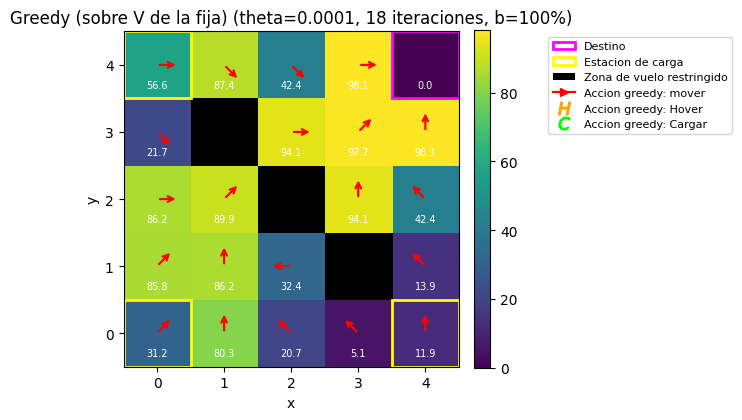

In [5]:
greedy = greedy_policy_from_V(env, V2)
V3, it3, t3, f3 = evaluate_and_report(env, greedy, "Greedy (sobre V de la fija)")

2. **Analizar la sensibilidad del resultado al valor de 𝛾 que propusieron en la Tarea 1. Repitan la evaluación con al menos dos valores adicionales de 𝛾 y discutan cómo cambian los valores y la política greedy resultante.**


3. **Identificar las limitaciones del modelo que implementaron respecto al problema real. ¿Qué aspectos del dominio de logística urbana no puede capturar este MDP? ¿Qué extensiones serían necesarias para que el modelo sea operacionalmente útil?**

Aunque el MDP implementado representa adecuadamente el problema planteado para fines académicos, todavía presenta varias simplificaciones respecto a un sistema real de logística urbana.

Entre las principales limitaciones se encuentran:

- Se modela únicamente un dron.
- Existe un único destino fijo.
- El clima y la congestión permanecen constantes durante todo el episodio.
- La ciudad está representada mediante una cuadrícula de únicamente 5×5 posiciones.
- La recarga de batería ocurre instantáneamente.
- No existen múltiples paquetes, prioridades de entrega ni ventanas de tiempo.
- No se consideran obstáculos dinámicos como otros drones, aves o edificios temporales.

Para que el modelo sea operacionalmente útil sería necesario incorporar múltiples drones, múltiples destinos, condiciones ambientales dinámicas, tiempos reales de recarga, prioridades de entrega, restricciones temporales y modelos más detallados del consumo de batería y del riesgo de vuelo.


In [6]:
print("Iteraciones")
print(f"Aleatoria: {it1}")
print(f"Fija: {it2}")
print(f"Greedy: {it3}")

estado = env.initial_state(0, 0)

print("\nValor del estado inicial")
print("Aleatoria:", V1[estado])
print("Fija:", V2[estado])
print("Greedy:", V3[estado])

Iteraciones
Aleatoria: 107
Fija: 20
Greedy: 18

Valor del estado inicial
Aleatoria: -350.0446723717185
Fija: 30.2723025195792
Greedy: 31.15329154718851


In [7]:
import pandas as pd

comparacion = []

for s in env.states:
    comparacion.append(
        {
            "Estado": s,
            "Aleatoria": V1[s],
            "Fija": V2[s],
            "Greedy": V3[s],
            "DifGreedyFija": V3[s] - V2[s],
        }
    )

df = pd.DataFrame(comparacion)
df.sort_values("DifGreedyFija", ascending=False).head(10)

,Estado,Aleatoria,Fija,Greedy,DifGreedyFija
170,"(1,4,b=10)",-157.996989,-149.970000,32.175992,182.145992
171,"(1,4,b=15)",-178.097523,-133.593400,44.397372,177.990772
108,"(1,0,b=15)",-176.155017,-150.689047,25.539346,176.228393
109,"(1,0,b=20)",-191.629079,-148.327042,26.607515,174.934557
24,"(0,1,b=15)",-164.023771,-148.816107,25.539346,174.355452
129,"(1,1,b=15)",-169.833541,-148.907542,25.125132,174.032674
25,"(0,1,b=20)",-176.119354,-144.717028,26.607515,171.324542
23,"(0,1,b=10)",-156.204922,-149.990296,10.139659,160.129956
107,"(1,0,b=10)",-156.204922,-149.990296,10.139659,160.129956
128,"(1,1,b=10)",-154.970691,-150.335336,9.725445,160.060782


**¿Cuál tiene mayor valor promedio?**

De acuerdo con los resultados obtenidos, la política greedy obtuvo los mayores valores esperados para la mayoría de los estados. En el estado inicial (0,0,b=100) el valor obtenido fue 31.15, mientras que la política determinista obtuvo 30.27 y la política aleatoria -350.04.

Esto indica que la política greedy logra aprovechar mejor la función de valor estimada, tomando decisiones que maximizan la recompensa esperada.

**¿En qué estados cambia más?**

Las mayores diferencias aparecen en los estados alejados del destino y en aquellos donde el dron debe decidir entre continuar avanzando o recargar batería. En estos estados la política aleatoria realiza movimientos poco eficientes que incrementan el costo esperado, mientras que las políticas fija y greedy seleccionan acciones más consistentes con el objetivo de alcanzar el destino minimizando el riesgo.

Cerca del destino las diferencias entre la política fija y la greedy son menores, ya que ambas suelen elegir movimientos similares.

**¿La política greedy supera a la fija?**

Sí, aunque la diferencia no es muy grande.

La política greedy obtuvo un valor ligeramente superior (31.15 frente a 30.27 en el estado inicial), lo que indica que la mejora obtenida al construir una política basada en la función de valor sí produce un mejor desempeño esperado.

La diferencia es relativamente pequeña porque la política fija diseñada manualmente ya seguía una estrategia razonable (avanzar hacia el destino y recargar cuando la batería es baja), por lo que la política greedy únicamente optimiza algunos estados específicos.


0.9 3.2696942869827375 18
0.95 19.0611860614185 19
0.98 30.2723025195792 20


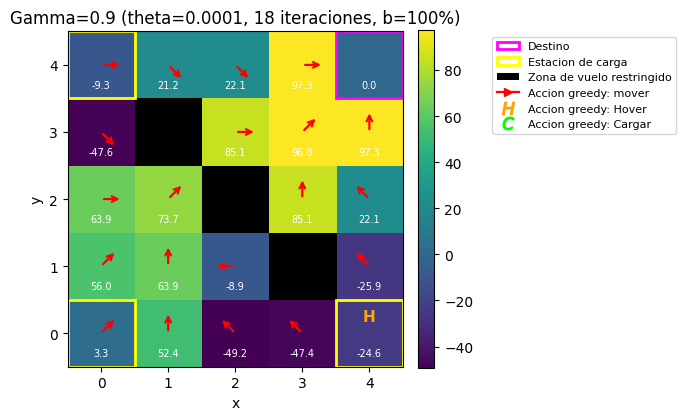

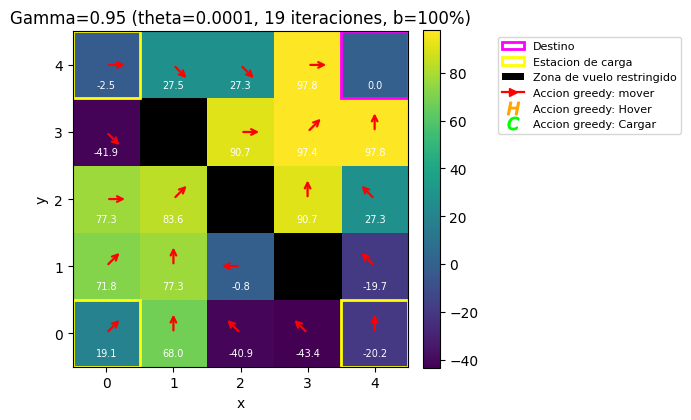

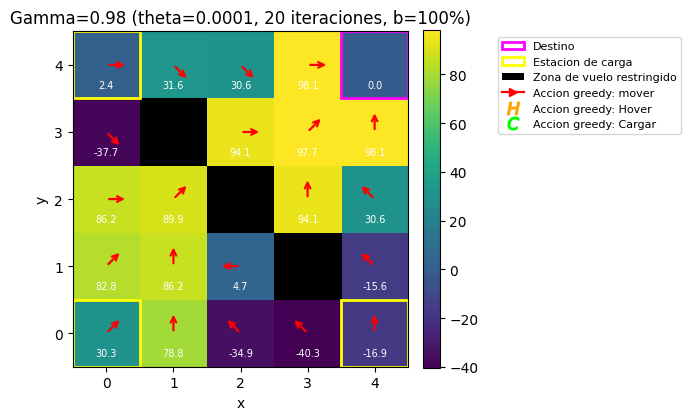

In [ ]:
gammas = [0.90, 0.95, 0.98]

for g in gammas:
    env = GridWorld(gamma=g)

    V, it, _, _ = evaluate_and_report(env, fixed_policy, f"Gamma={g}")

    s0 = env.initial_state(0, 0)
    print(g, V[s0], it)

## Sensibilidad al factor de descuento γ

Se evaluó el modelo utilizando tres valores distintos del factor de descuento:

| γ    | Valor del estado inicial | Iteraciones |
| ---- | ------------------------ | ----------- |
| 0.90 | 3.27                     | 18          |
| 0.95 | 19.06                    | 19          |
| 0.98 | 30.27                    | 20          |

Al disminuir el valor de γ, el agente prioriza las recompensas inmediatas y reduce la importancia de las recompensas futuras. Esto provoca que los valores esperados de los estados disminuyan considerablemente.

Con γ = 0.90 el valor esperado es mucho menor, ya que el agente prácticamente no considera el beneficio de llegar al destino en el largo plazo.

Con γ = 0.95 el comportamiento mejora y comienza a valorar más las recompensas futuras.

Finalmente, con γ = 0.98 se obtienen los valores más altos, ya que el agente planifica a más largo plazo y considera que alcanzar el destino compensa los costos intermedios de tiempo, batería y riesgo.

En las pruebas realizadas la estructura general de la política greedy no cambió significativamente entre γ = 0.95 y γ = 0.98; sin embargo, los valores de los estados sí aumentaron de forma considerable conforme γ se acerca a 1.


# Dictamen técnico

Con base en los resultados obtenidos, se concluye que el MDP diseñado constituye una base adecuada para representar el problema de despacho de drones y evaluar distintas estrategias de navegación.

La comparación entre políticas muestra que la política aleatoria produce valores significativamente inferiores, mientras que la política determinista mejora considerablemente el desempeño al incorporar conocimiento del dominio. La política greedy derivada de la función de valor obtiene los mejores resultados, aunque la mejora respecto a la política determinista es moderada debido a que esta última ya seguía una estrategia razonable.

El análisis de sensibilidad demuestra que el valor del factor de descuento tiene un impacto importante sobre la valoración de los estados. Valores altos de γ permiten planificar considerando beneficios futuros, mientras que valores menores producen estrategias más enfocadas en recompensas inmediatas.

No obstante, el modelo implementado todavía simplifica diversos aspectos importantes del problema real, como la existencia de múltiples drones, condiciones climáticas variables, múltiples entregas, tiempos de recarga y restricciones operacionales.

## Recomendación

Se recomienda utilizar este MDP como una primera aproximación para validar el diseño del problema y comparar estrategias de decisión. Sin embargo, antes de implementar un sistema de aprendizaje por refuerzo en un entorno operativo, sería conveniente ampliar el modelo incorporando condiciones ambientales dinámicas, múltiples drones, múltiples destinos, ventanas de tiempo y un modelo de batería más realista. Posteriormente podría aplicarse un algoritmo de control como Value Iteration, Policy Iteration o Q-Learning para obtener políticas óptimas sobre un modelo más cercano al entorno real.
